[-2.35619449 -1.89254688 -1.24904577 -0.78539816 -2.8198421  -2.35619449
 -0.78539816 -0.32175055  2.8198421   2.35619449  0.78539816  0.32175055
  2.35619449  1.89254688  1.24904577  0.78539816]
[1.34164079 1.         1.         1.34164079 1.         0.4472136
 0.4472136  1.         1.         0.4472136  0.4472136  1.
 1.34164079 1.         1.         1.34164079]
[-0.9486833  -0.31622777  0.31622777  0.9486833  -0.9486833  -0.31622777
  0.31622777  0.9486833  -0.9486833  -0.31622777  0.31622777  0.9486833
 -0.9486833  -0.31622777  0.31622777  0.9486833 ]


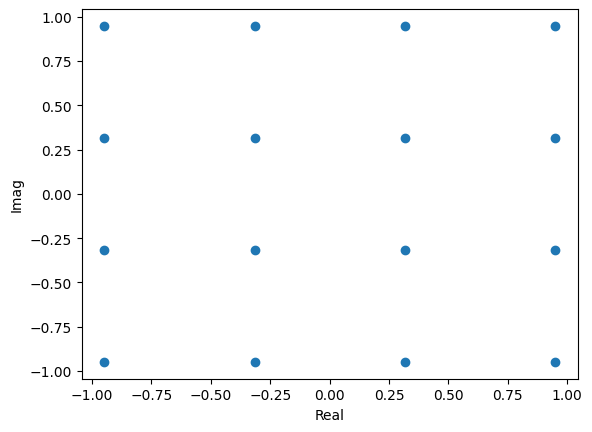

In [344]:
import numpy as np
from scipy import signal, fft
import komm
from matplotlib import pyplot as plt
from tools import *
from pathlib import Path

np.random.seed(0)

DWIDTH = 16
DFRAC  = 12

msg = "A perfectly acceptable example of an extremely verbose message of large words and many characters!!!"
M = 16
fc = 1e6
br = 50e3
fs = 5e6
sps = int(fs / br)
sps_rx = 10
snr = 15
Es = 1.0
B = 350e3 # channel BW

sync_len = 64
zadoff_chu_len = 16
span = 8
beta = 0.5

constellation = get_const(f'{M}-QAM', Es)
print(np.angle(constellation))
print(np.abs(constellation))
print(np.real(constellation))
write_mem_file(constellation, DWIDTH, DFRAC, 'const.mem', complex=True, sep=' ')
plot_constellation(constellation)
plt.show()

C:\Users\sidal\AppData\Local\Temp\ipykernel_33136\100042423.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


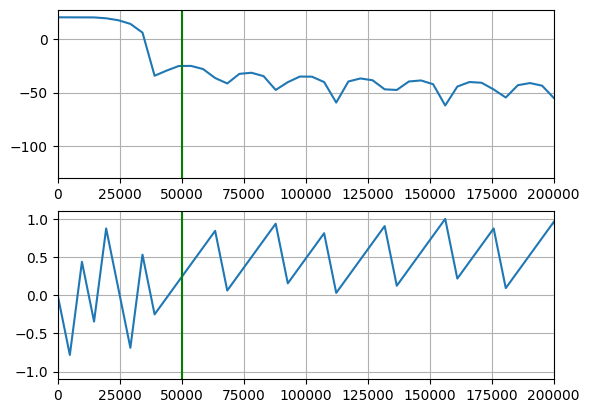

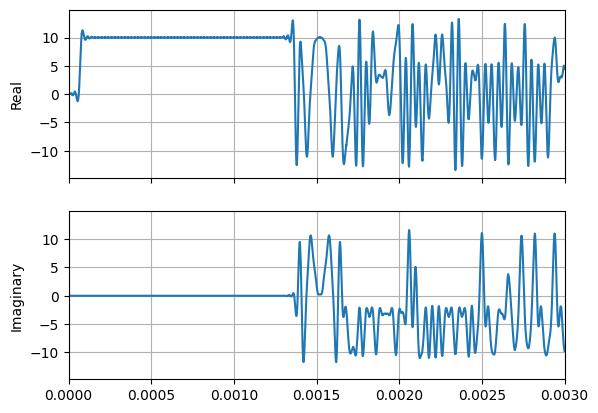

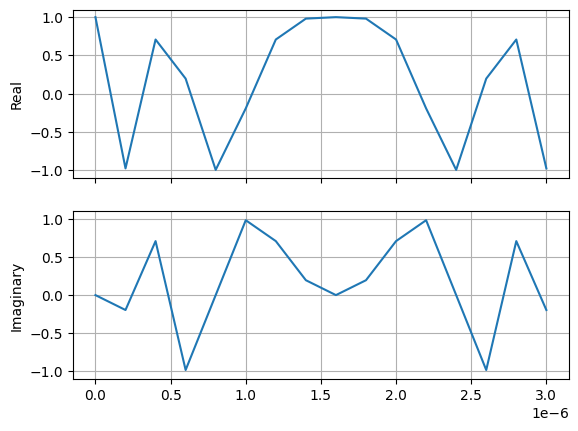

In [345]:
words = str2words(msg, M)
symbs = constellation[words]
sync_symbs = np.ones(sync_len) + 0j
zadoff_chu_seq = zadoff_chu(zadoff_chu_len)
write_mem_file(zadoff_chu_seq, DWIDTH, DFRAC, 'zadoff_chu.mem', complex=True, sep=' ')

rrc = get_rrc_pulse(beta, span, sps)
w, h = signal.freqz(rrc, fs=fs)
fig, (ax0, ax1) = plt.subplots(2, 1)
ax0.plot(w, 20*np.log10(np.abs(h)))
ax1.plot(w, np.angle(h)/np.pi)
for axis in [ax0, ax1]:
  axis.axvline(x=br, color='g')
  axis.set_xlim([0, br*4])
  axis.grid()
fig.show()
rrc_up = rrc if len(rrc)%sps == 0 else np.pad(rrc, (0, sps - (len(rrc)%sps)))
write_mem_file(rrc_up, DWIDTH, DFRAC, 'rrc.mem', complex=False)

dn = sps // sps_rx
dn_filt_size = ((span*sps_rx)+1)*dn
rrc_dn = np.reshape(np.pad(rrc, (0, dn_filt_size-len(rrc))), ((span*sps_rx)+1, dn)).T
if not Path('./rrc').exists():
  Path('./rrc').mkdir()
for n in range(len(rrc_dn)):
  write_mem_file(rrc_dn[n], DWIDTH, DFRAC, f'rrc/rrc_d{n}.mem', complex=False)
# write_mem_file(rrc_dn.flatten(), DWIDTH, DFRAC, 'rrc_dn.mem')

# full_msg = np.convolve(upsample(np.concat((sync_symbs, zadoff_chu_seq, symbs)), sps), rrc)
full_msg = signal.resample_poly(np.pad(np.concat((sync_symbs, zadoff_chu_seq, symbs)), span//2), sps, 1, window=rrc)

fig, ax1, ax2 = plot_complex_time_sequence(full_msg, fs)
plt.xlim((0.0000, 0.003))
plt.show()

# X = fft.fftshift(fft.fft(full_msg))
# f = fft.fftshift(fft.fftfreq(len(X), fs))
# plt.figure(figsize=(20,5))
# plt.plot(f, 10*np.log10(np.abs(X)))
# Z = fft.fftshift(fft.fft(np.pad(zadoff_chu_seq, len(zadoff_chu_seq)*2)))
# f = fft.fftshift(fft.fftfreq(len(Z), fs))
# plt.plot(f, 10*np.log10(np.abs(Z)))
# plt.grid()
# plt.show()
plot_complex_time_sequence(zadoff_chu_seq, fs)
plt.show()

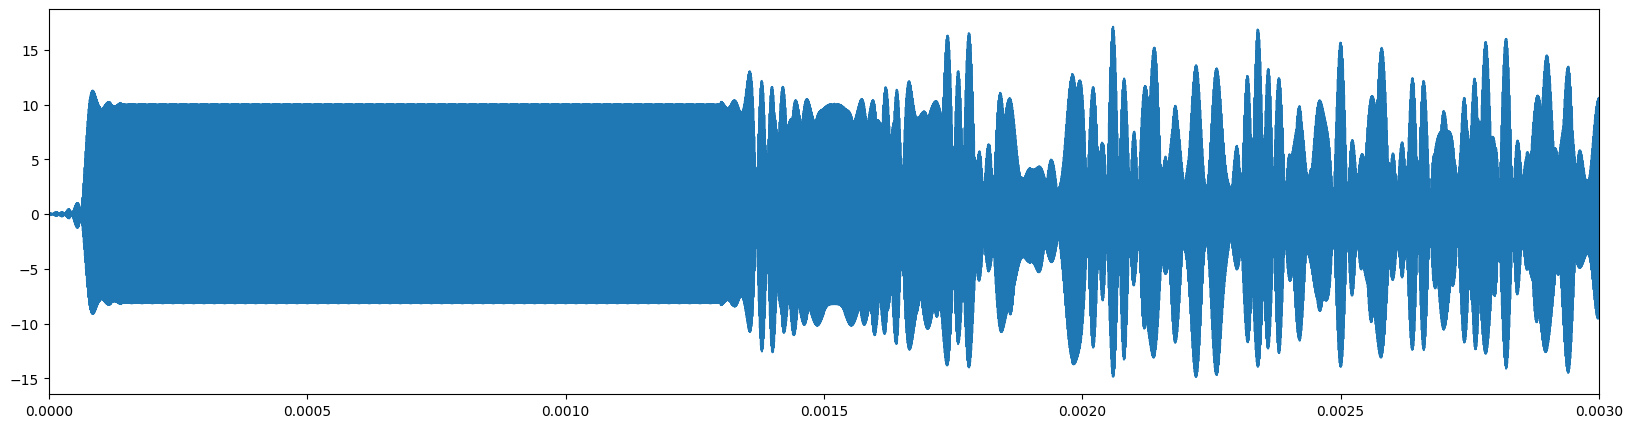

TransferFunctionDiscrete(
array([ 0.03349282,  0.        , -0.03349282]),
array([ 1.        , -1.89473684,  0.93301435]),
dt: 2e-07
)
0.003267518486828846


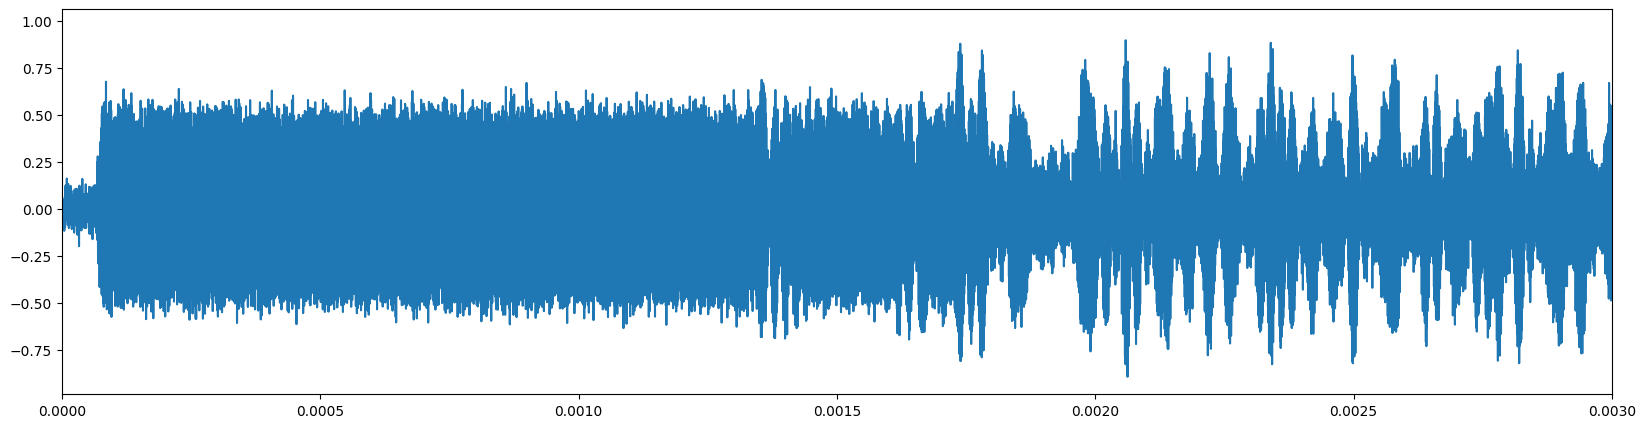

In [346]:
t = np.arange(0, len(full_msg)) / fs
x = np.real(full_msg * np.exp(2j*np.pi*fc*t))

plt.figure(figsize=(20, 5))
plt.plot(t, x)
plt.xlim((0.000, 0.003))
plt.show()

channel = signal.TransferFunction([0, B, 0], [1, B, fc**2])
discrete_channel = signal.cont2discrete(channel, 1/fs, 'bilinear')
print(discrete_channel)
trx, chout = signal.dlsim(discrete_channel, x, t)
yout = np.squeeze(chout)
snr_linear = 10**(snr/10)
signal_power = np.sum(np.abs(yout)**2)/len(yout)
noise_power = signal_power / snr_linear
print(noise_power)
awgn = komm.GaussianChannel(noise_power)
noisy_chout = awgn.transmit(yout)

plt.figure(figsize=(20, 5))
plt.plot(trx, noisy_chout)
plt.xlim((0.000, 0.003))
plt.show()


[0.02874491 0.07824374 0.13859177 0.18461287 0.19455916 0.16355735
 0.10957305 0.06096047 0.02986674 0.00783385 0.00345609]


C:\Users\sidal\AppData\Local\Temp\ipykernel_33136\2725287668.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


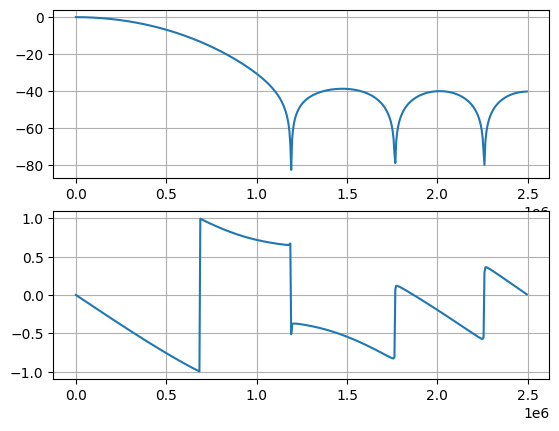

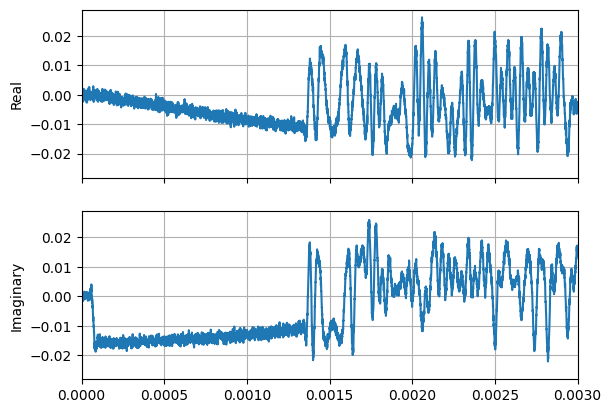

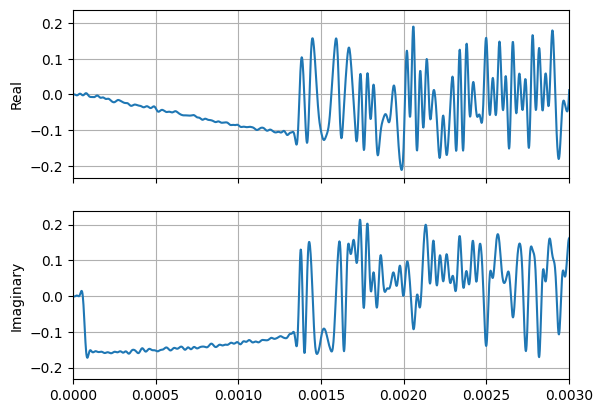

In [347]:
phase_offset = 11*np.pi/37
cfo = fc * 0.0001
gain = 0.025

lo = gain * np.exp(-2j*np.pi*(fc + cfo)*trx + phase_offset)

# demod_filt = signal.iirdesign(wp=(fc/8), ws=(fc/2), gpass=1, gstop=120, ftype='cheby2', fs=fs, output='sos')
# y = signal.sosfilt(demod_filt, (noisy_chout * lo)).T
# w, h = signal.freqz_sos(demod_filt, fs=fs)
# fig, (ax0, ax1) = plt.subplots(2, 1)
# ax0.plot(w, 20*np.log10(np.abs(h)))
# ax0.grid()
# ax1.plot(w, np.angle(h)/np.pi)
# ax1.grid()
# fig.show()
# for i in range(len(demod_filt)):
#   write_mem_file(demod_filt[i][0:3], DWIDTH, DFRAC, f"demod_iir_{i}_num.mem")
#   write_mem_file(demod_filt[i][3:6], DWIDTH, DFRAC, f"demod_iir_{i}_den.mem")

demod_filt = signal.minimum_phase(signal.firwin(11, fc/4, fs=fs), half=False)
# demod_filt = signal.firwin(7, fc/4, fs=fs)
y = np.convolve((noisy_chout * lo), demod_filt, 'same')
w, h = signal.freqz(demod_filt, fs=fs)
fig, (ax0, ax1) = plt.subplots(2, 1)
ax0.plot(w, 20*np.log10(np.abs(h)))
ax0.grid()
ax1.plot(w, np.angle(h)/np.pi)
ax1.grid()
fig.show()
write_mem_file(demod_filt, DWIDTH, DFRAC, "demod_fir.mem")

print(demod_filt)

# y = noisy_chout * lo

plot_complex_time_sequence(y, fs)
plt.xlim((0, 0.003))
plt.show()

# yhat = np.convolve(np.squeeze(y), rrc, 'same')
yhat = signal.resample_poly(np.squeeze(y), 1, sps//sps_rx, window=rrc)
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
plt.xlim((0, 0.003))
plt.show()
# animate_complex_sequence(yhat[t < 0.00125], 'Simulated CFO', 'cfo.mp4', sps=360)

[ 0.33806384+5.12538501e-18j  0.29668916+1.08553763e-02j
  0.23521765+2.47907575e-02j  0.15728357+4.09519754e-02j
  0.06817896+5.79573193e-02j -0.02559835+7.39674685e-02j
 -0.11693983+8.68312060e-02j -0.19879948+9.42986699e-02j
 -0.26486961+9.42832136e-02j -0.31018224+8.51437233e-02j
 -0.33156803+6.59529827e-02j -0.32803758+3.61343304e-02j
 -0.30047885-2.65357389e-03j -0.25181305-4.81500903e-02j
 -0.18653419-9.71179094e-02j -0.11020547-1.45590539e-01j
 -0.0288782 -1.89224162e-01j  0.05149561-2.23718173e-01j
  0.12558904-2.45257937e-01j  0.18910854-2.50928202e-01j
  0.23904723-2.39047231e-01j  0.2741879 -2.09799068e-01j
  0.2937638 -1.64035745e-01j  0.29844495-1.04378187e-01j
  0.2896999 -3.46312378e-02j  0.26948137+4.05623676e-02j
  0.23992561+1.16147815e-01j  0.20310525+1.87115356e-01j
  0.16086246+2.48937700e-01j  0.11473258+2.97940436e-01j
  0.06595298+3.31568035e-01j  0.01611903+3.48406459e-01j
 -0.03445444+3.48535080e-01j -0.08495742+3.33075812e-01j
 -0.13446456+3.04065574e-01j -0

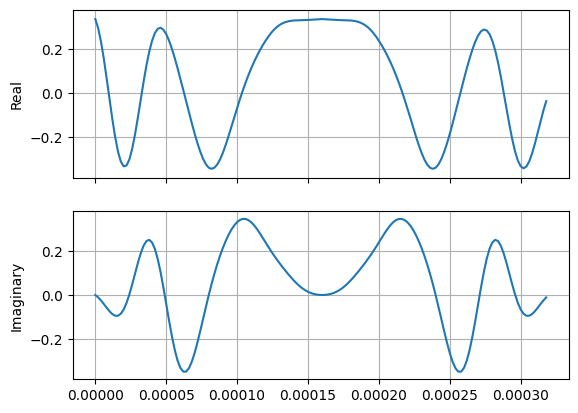

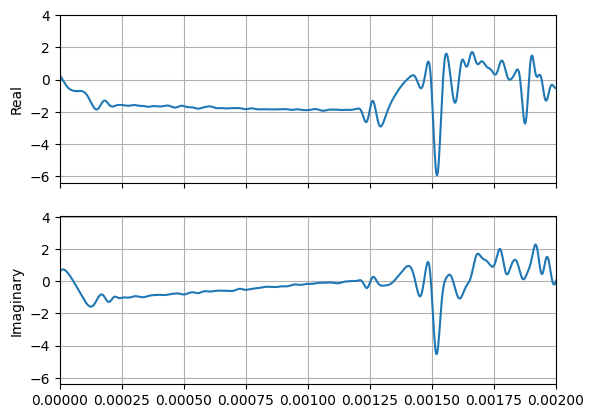

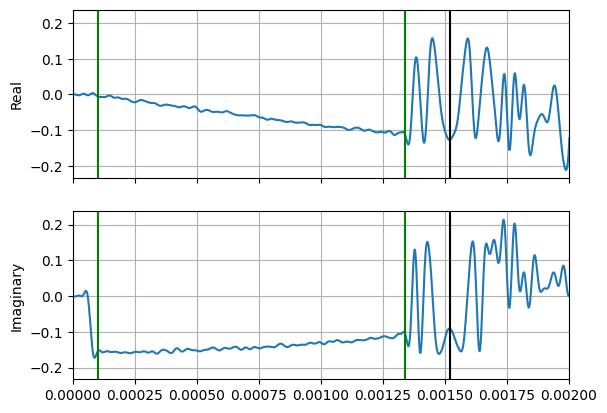

In [348]:
zch_rc = np.convolve(upsample(zadoff_chu_seq, sps_rx), get_rc_pulse(beta, span, sps_rx), 'same')
plot_complex_time_sequence(zch_rc, fs / sps_rx)
# Convolving with reversed and conjugated window has the effect of cross correlation
write_mem_file(np.conj(zch_rc)[::-1], DWIDTH+4, DFRAC, 'zadoff_chu_rc.mem', complex=True, sep=' ')
print(np.conj(zch_rc))
xcorr = np.abs(np.correlate(yhat, zch_rc, 'same'))
plot_complex_time_sequence(np.correlate(yhat, zch_rc, 'same'), br*sps_rx)
plt.xlim((0, 0.002))
plt.show()
sync_point = np.argmax(xcorr)
pilot_end = sync_point - (sps_rx + len(zch_rc)//2)
pilot_start = pilot_end - (sync_len*sps_rx) + (sps_rx*2)
msg_start = sync_point + ((zadoff_chu_len)*sps_rx)//2 - 1

# plot_complex_time_sequence(xcorr, br*sps_rx)
t_sps_rx = np.arange(0, len(yhat)) / (br*sps_rx)
# plt.figure()
# plt.plot(t_sps_rx, np.real(yhat), 'o-')
# plt.plot(t_sps_rx, np.imag(yhat), 'o-')
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
plt.xlim((0, 0.002))
plt.show()
        

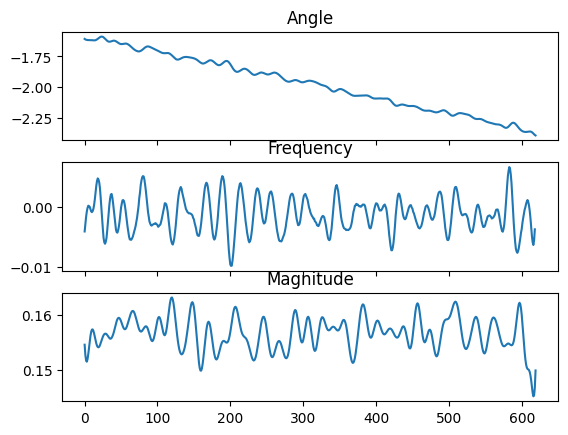

In [349]:
pilot_tone = yhat[pilot_start:pilot_end]
phase_err = np.angle(pilot_tone)
frq_err = phase_err[1:] - phase_err[:-1]
mag_err = np.abs(pilot_tone)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
ax1.set_title('Angle')
ax2.set_title('Frequency')
ax3.set_title('Magnitude')
ax1.plot(phase_err)
ax2.plot(frq_err)
ax3.plot(mag_err)
plt.show()
freq_est = np.mean(frq_err[np.abs(frq_err) < np.pi])
phase_est = np.angle(yhat[pilot_start]) - (freq_est*pilot_start)
mag_est = np.mean(mag_err)


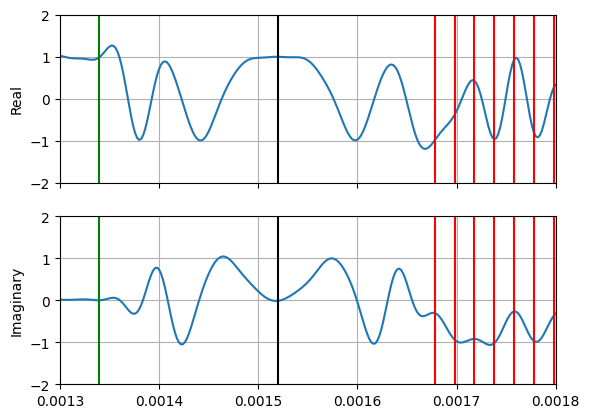

In [350]:
zhat = yhat / (mag_est*np.exp(1j*(np.arange(len(yhat))*freq_est + phase_est)))
# zhat = yhat
fig, ax1, ax2 = plot_complex_time_sequence(zhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
  for i in range(len(words)):
    axis.axvline(x=(t_sps_rx[msg_start + (i*sps_rx)]), color='r')
  
# xhat = signal.resample_poly(full_msg, 1, sps//sps_rx, window=rrc) / 120
# ax1.plot(np.arange(len(xhat))/(br*sps_rx), np.real(xhat))
# ax2.plot(np.arange(len(xhat))/(br*sps_rx), np.imag(xhat))

plt.xlim((0.0013, 0.0018))
plt.ylim((-2, 2))
plt.show()

0.0


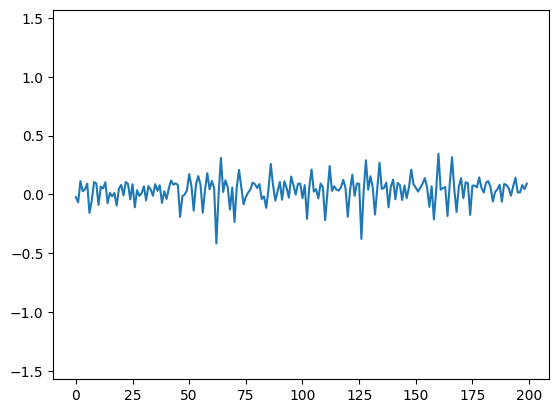

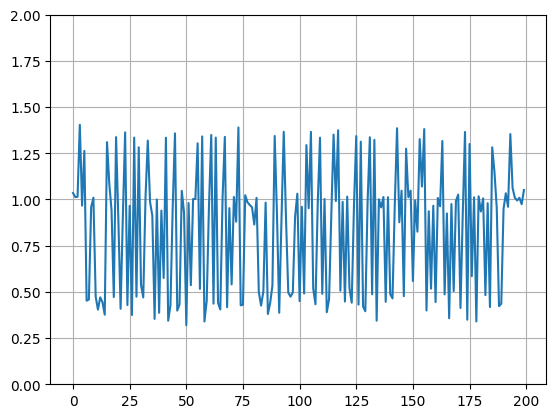

In [351]:
mhat = downsample(zhat[msg_start:], sps_rx)[:len(words)]
s_hat, phase_offsets = min_dist_detection(mhat, constellation, phase_offsets=True)
print(calc_error_rate(symbs, s_hat))
plt.figure()
plt.plot(phase_offsets)
plt.ylim([-np.pi/2, np.pi/2])
plt.show()
plt.figure()
plt.plot(np.abs(mhat))
plt.grid()
# plt.xlim([1000, 2000])
plt.ylim([0, 2])
plt.show()

In [352]:
w_hat = np.empty_like(s_hat, dtype=np.uint8)
for i in range(M):
  w_hat[s_hat == constellation[i]] = i
print(words2str(w_hat, M))

A perfectly acceptable example of an extremely verbose message of large words and many characters!!!


[[ 0.44508427 -0.89016855  0.44508427  1.         -1.45970625  0.53482598]
 [ 1.         -2.          1.          1.         -1.51329077  0.59116807]
 [ 1.         -2.          1.          1.         -1.6234057   0.70694977]
 [ 1.         -2.          1.          1.         -1.79396185  0.88628311]]


C:\Users\sidal\AppData\Local\Temp\ipykernel_33136\2819537322.py:8: RuntimeWarning: divide by zero encountered in log10
  ax0.plot(w, 20*np.log10(np.abs(h)))
C:\Users\sidal\AppData\Local\Temp\ipykernel_33136\2819537322.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


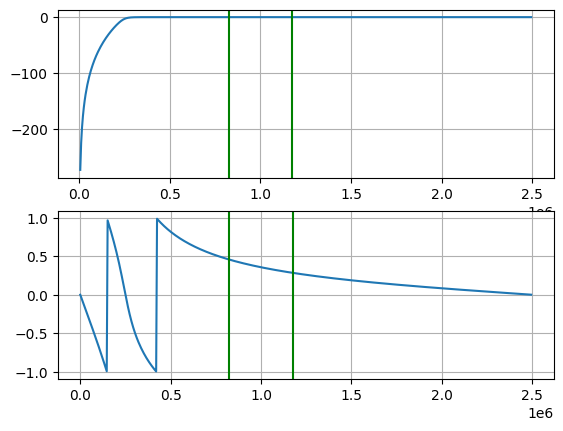

In [353]:
# rx_filt = signal.iirdesign(wp=(fc - B/2, fc + B/2), ws=(fc - B, fc + B), 
#                            gpass=1, gstop=40, output='sos', fs=fs)
# rx_filt = signal.iirfilter(N=3, Wn=(fc - B, fc + B), rs=6, rp=0.1,
#                            btype='bandpass', ftype='ellip', output='sos', fs=fs)
rx_filt = signal.iirfilter(N=8, Wn=(fc/4), btype='highpass', output='sos', fs=fs)
w, h = signal.freqz_sos(rx_filt, fs=fs)
fig, (ax0, ax1) = plt.subplots(2, 1)
ax0.plot(w, 20*np.log10(np.abs(h)))
ax0.grid()
ax1.plot(w, np.angle(h)/np.pi)
ax1.grid()
for axis in [ax0, ax1]:
  axis.axvline(x=(fc+(B/2)), color='g')
  axis.axvline(x=(fc-(B/2)), color='g')
fig.show()
print(rx_filt)
write_mem_file(rx_filt.flatten(), DWIDTH, DFRAC, "rx_iir.mem")